# PISA 2025 Insight Report: Mongolia and Rwanda

This report compares PISA 2025<sup><a href="#endnote-1">1</a></sup> performance in Mongolia and Rwanda with a pooled OECD comparison group. Mathematics is the primary outcome, with science and reading providing context. The analysis examines socioeconomic status (ESCS), gender, grade repetition, school location, and material and staff shortages. Achievement estimates use student weights and all 10 plausible values. Findings are descriptive rather than causal; missing-data patterns and a school-location anomaly limit some comparisons.

# 1. Package Imports

In [1]:
# importing/installing the required packages
!pip install pyreadstat

import pandas as pd
import gdown # used to download the PISA files directly from Google drive
import pyreadstat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Downloading PISA Files

In [2]:
# assigning file names in this Colab session
student_file = "CY09_MS_STU_PUF.sav"
school_file = "CY09_MS_SCH_PUF.sav"

# download the files from the shared Google Drive
gdown.download(
    id="163VOjSHyLiuVDj4pZRX9g5sSeMBn3FXO",
    output=student_file
)

gdown.download(
    id="1VZyjoUiPhUBnxFBOJPqmRBDjAmGg0smZ",
    output=school_file
)

Downloading...
From (original): https://drive.google.com/uc?id=163VOjSHyLiuVDj4pZRX9g5sSeMBn3FXO
From (redirected): https://drive.google.com/uc?id=163VOjSHyLiuVDj4pZRX9g5sSeMBn3FXO&confirm=t&uuid=23aad563-63c9-43b8-b147-92b172e5bd29
To: C:\Users\Isomo\Documents\GitHub\canvas-assignment-manager\semester 1\python programming ii\final project\.submission-worktree\CY09_MS_STU_PUF.sav


  0%|          | 0.00/2.17G [00:00<?, ?B/s]

  0%|          | 524k/2.17G [00:00<07:44, 4.67MB/s]

  0%|          | 4.72M/2.17G [00:00<01:31, 23.7MB/s]

  1%|          | 13.6M/2.17G [00:00<00:42, 51.3MB/s]

...

 15%|█▍        | 2.62M/17.9M [00:00<00:01, 13.5MB/s]

 38%|███▊      | 6.82M/17.9M [00:00<00:00, 17.7MB/s]

 85%|████████▌ | 15.2M/17.9M [00:00<00:00, 27.5MB/s]

100%|██████████| 17.9M/17.9M [00:00<00:00, 26.8MB/s]

'CY09_MS_SCH_PUF.sav'

# 3. Data Loading and Column Selection



## 3A. Load School Data

In [3]:
# loading the PISA school dataset
school_df = pd.read_spss(
   school_file,
   convert_categoricals=False
)

school_df = school_df[["CNT", "OECD", "CNTSCHID", "SC001Q01TA", "EDUSHORT", "STAFFSHORT"]]

# school integrity checks
print(school_df.shape)
display(school_df.head())


(25133, 6)


,CNT,OECD,CNTSCHID,SC001Q01TA,EDUSHORT,STAFFSHORT
0,ALB,0.0,00800001,3.0,-0.0703,0.0053
1,ALB,0.0,00800002,NaN,NaN,NaN
2,ALB,0.0,00800003,1.0,-0.6481,-0.7828
3,ALB,0.0,00800004,4.0,-1.4210,-1.4549
4,ALB,0.0,00800005,3.0,NaN,NaN


## 3B. Select and Load Student Data

In [4]:
# defining the student columns so we don't load the entire student database at once
student_cols = [
    # IDs / country
    "CNT",
    "OECD",
    "CNTSCHID",
    "CNTSTUID",

    # Student characteristics
    "ESCS",
    "MALE",
    "REPEAT",

    # Sampling weight
    "W_FSTUWT",

    # Mathematics plausible values
    "PV1MATH", "PV2MATH", "PV3MATH", "PV4MATH", "PV5MATH",
    "PV6MATH", "PV7MATH", "PV8MATH", "PV9MATH", "PV10MATH",

    # Reading plausible values
    "PV1READ", "PV2READ", "PV3READ", "PV4READ", "PV5READ",
    "PV6READ", "PV7READ", "PV8READ", "PV9READ", "PV10READ",

    # Science plausible values
    "PV1SCIE", "PV2SCIE", "PV3SCIE", "PV4SCIE", "PV5SCIE",
    "PV6SCIE", "PV7SCIE", "PV8SCIE", "PV9SCIE", "PV10SCIE"
]

# loading the PISA student dataset
student_df = pd.read_spss(
    student_file,
    usecols=student_cols,
    convert_categoricals=False
)

# student df integrity checks
print(student_df.shape)
display(student_df.head())

(755721, 38)


,CNT,CNTSCHID,CNTSTUID,OECD,MALE,ESCS,REPEAT,W_FSTUWT,PV1SCIE,PV2SCIE,...,PV1READ,PV2READ,PV3READ,PV4READ,PV5READ,PV6READ,PV7READ,PV8READ,PV9READ,PV10READ
0,ALB,00800001,00800001,0.0,1.0,-1.100674,0.0,2.579892,289.678433,330.597936,...,283.163374,279.086277,274.747784,297.514118,252.215220,261.605882,318.809555,305.916947,273.445407,281.563818
1,ALB,00800001,00800002,0.0,0.0,-1.930787,0.0,2.681028,416.224453,417.555856,...,410.218507,429.397648,459.153008,392.216504,378.088216,382.526163,397.147249,390.487895,426.057381,393.334048
2,ALB,00800001,00800003,0.0,0.0,-1.078518,0.0,2.681028,488.596531,505.993468,...,423.163736,462.508141,451.681181,433.973068,476.261765,379.951141,484.955984,445.408461,448.122404,449.039724
3,ALB,00800001,00800004,0.0,0.0,-0.018204,0.0,2.681028,326.012761,370.805787,...,421.192543,410.559230,381.297720,404.600264,370.701767,402.860605,396.898745,374.877660,409.893702,419.352772
4,ALB,00800001,00800005,0.0,0.0,-1.071648,0.0,2.681028,348.666297,389.462758,...,331.749128,453.013815,389.342198,396.983202,486.666439,376.823069,471.375222,404.796673,417.852539,355.165729


# 4. Column Standardization

## 4A. Standardize School Column Names

In [5]:
#rename school columns
school_df = school_df.rename(columns={
    "CNT": "country",
    "OECD": "is_oecd",
    'CNTSCHID': 'school_id',
    'SC001Q01TA': 'school_location',
    'EDUSHORT': 'edu_material_shortage',
    'STAFFSHORT': 'staff_shortage'
})

# school df integrity check
school_df.head()

,country,is_oecd,school_id,school_location,edu_material_shortage,staff_shortage
0,ALB,0.0,00800001,3.0,-0.0703,0.0053
1,ALB,0.0,00800002,NaN,NaN,NaN
2,ALB,0.0,00800003,1.0,-0.6481,-0.7828
3,ALB,0.0,00800004,4.0,-1.4210,-1.4549
4,ALB,0.0,00800005,3.0,NaN,NaN


## 4B. Standardize Student Column Names

In [6]:
# rename student columns

rename_dict = {
    'CNT': 'country',
    'OECD' : 'is_oecd',
    'CNTSCHID': 'school_id',
    'CNTSTUID': 'student_id',
    'MALE': 'is_male',
    'ESCS': 'socioeconomic_index',
    'REPEAT': 'grade_repetition',
    'W_FSTUWT': 'student_weight'
}

for i in range(1, 11):
    rename_dict[f'PV{i}SCIE'] = f'science{i}'
    rename_dict[f'PV{i}MATH'] = f'math{i}'
    rename_dict[f'PV{i}READ'] = f'read{i}'

student_df = student_df.rename(columns=rename_dict)

# student df integrity check
student_df.head()

,country,school_id,student_id,is_oecd,is_male,socioeconomic_index,grade_repetition,student_weight,science1,science2,...,read1,read2,read3,read4,read5,read6,read7,read8,read9,read10
0,ALB,00800001,00800001,0.0,1.0,-1.100674,0.0,2.579892,289.678433,330.597936,...,283.163374,279.086277,274.747784,297.514118,252.215220,261.605882,318.809555,305.916947,273.445407,281.563818
1,ALB,00800001,00800002,0.0,0.0,-1.930787,0.0,2.681028,416.224453,417.555856,...,410.218507,429.397648,459.153008,392.216504,378.088216,382.526163,397.147249,390.487895,426.057381,393.334048
2,ALB,00800001,00800003,0.0,0.0,-1.078518,0.0,2.681028,488.596531,505.993468,...,423.163736,462.508141,451.681181,433.973068,476.261765,379.951141,484.955984,445.408461,448.122404,449.039724
3,ALB,00800001,00800004,0.0,0.0,-0.018204,0.0,2.681028,326.012761,370.805787,...,421.192543,410.559230,381.297720,404.600264,370.701767,402.860605,396.898745,374.877660,409.893702,419.352772
4,ALB,00800001,00800005,0.0,0.0,-1.071648,0.0,2.681028,348.666297,389.462758,...,331.749128,453.013815,389.342198,396.983202,486.666439,376.823069,471.375222,404.796673,417.852539,355.165729


# 5. Data Cleaning & Missingness Analysis


## 5A. Define Missing-Value Codes

In [7]:
# mapping missing value codes to NA:

# common PISA missing-value codes
missing_95_99 = [95, 96, 97, 98, 99]
missing_repeat = [5, 6, 7, 8, 9]
missing_plausible_value = [9997]
missing_school_id = ['9999997']

# missing-value code translation:
# 95 = valid skip
# 96 = system missing
# 97 = not administered / not applicable
# 98 = invalid
# 99 = no response

# for repeat:
# 5 = valid skip
# 6 = system missing
# 7 = not administered / not applicable
# 8 = invalid
# 9 = no response

# for plausible values:
# 9997 = not administered



## 5B. Map Missing Codes to Variables

In [8]:
# mapping missing codes for school variables
school_missing_values = {
    "school_id": missing_school_id,
    "school_location": missing_95_99,
    "edu_material_shortage": missing_95_99,
    "staff_shortage": missing_95_99
}


# mapping missing codes for student variables
student_missing_values = {
    "country": [],
    "is_oecd": [],
    "school_id": missing_school_id,
    "student_id": [],
    "socioeconomic_index": missing_95_99,
    "is_male": missing_95_99,
    "grade_repetition": missing_repeat,
    "student_weight": []
}

for i in range(1, 11):
    student_missing_values[f"math{i}"] = missing_plausible_value
    student_missing_values[f"read{i}"] = missing_plausible_value
    student_missing_values[f"science{i}"] = missing_plausible_value

## 5C. Create Analysis Groups

In [9]:
# creating analysis groups for school data
school_df["analysis_group"] = np.select(
    [
        school_df["country"] == "MNG",
        school_df["country"] == "RWA",
        school_df["is_oecd"] == 1
    ],
    [
        "Mongolia",
        "Rwanda",
        "OECD"
    ],
    default="Other"
)


# creating analysis groups for student data
student_df["analysis_group"] = np.select(
    [
        student_df["country"] == "MNG",
        student_df["country"] == "RWA",
        student_df["is_oecd"] == 1
    ],
    [
        "Mongolia",
        "Rwanda",
        "OECD"
    ],
    default="Other"
)

## 5D. Clean School Data and Check Missingness

In [10]:
# assigning NA values to school_df missing codes

school_clean = school_df.copy()
for column, missing_codes in school_missing_values.items():
    school_clean[column] = (
        school_clean[column]
        .replace(missing_codes, np.nan)
    )

# defining school columns for the NA analysis
school_missing_cols = [
    "school_location",
    "edu_material_shortage",
    "staff_shortage"
]

# mean school df missingness:
school_missing = (
    school_clean[
        school_clean["analysis_group"].isin(
            ["Mongolia", "Rwanda", "OECD"]
        )
    ]
    .groupby("analysis_group")[school_missing_cols]
    .agg(lambda x: x.isna().mean() * 100)
    .round(2)
)

# check missing identifiers
school_id_cols = [
    "country",
    "is_oecd",
    "school_id"
]

# identifiers mean missingness
school_id_missing = (
    school_clean
    .groupby("analysis_group")[school_id_cols]
    .agg(lambda x: x.isna().mean() * 100)
    .round(2)
)

# printing tables for verification
print("=== Missing data for School Dataframe ===")
display(school_missing)
print("=== Missing ids for School Dataframe ===")
display(school_id_missing.loc[["Mongolia", "Rwanda", "OECD"]])


# making sure that CNTSCHID is unique
assert school_clean["school_id"].is_unique

=== Missing data for School Dataframe ===


,school_location,edu_material_shortage,staff_shortage
analysis_group,,,
Mongolia,1.05,0.52,2.09
OECD,12.04,13.67,13.59
Rwanda,1.88,0.00,0.00


=== Missing ids for School Dataframe ===


,country,is_oecd,school_id
analysis_group,,,
Mongolia,0.0,0.0,0.0
Rwanda,0.0,0.0,0.0
OECD,0.0,0.0,0.0


## 5E. School Missingness Visualization

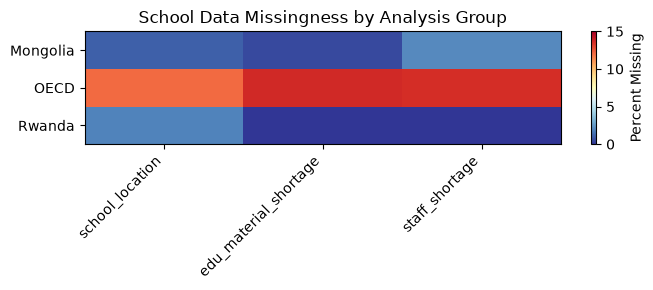

In [11]:
# keeping only missing school variables with some missing data
missing_school_plot = school_missing.loc[
    :, school_missing.max() > 0
]

# creating school missingness plot
plt.figure(figsize=(7, 3))
plt.imshow(missing_school_plot, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=15)
plt.xticks(
    range(len(missing_school_plot.columns)),
    missing_school_plot.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(missing_school_plot.index)),
    missing_school_plot.index
)

# customizing school missingness plot
plt.colorbar(label="Percent Missing")
plt.title("School Data Missingness by Analysis Group")
plt.tight_layout()
plt.show()

## 5F. Clean Student Data and Check Missingness

In [12]:
# assigning NA values to student_df missing codes

student_clean = student_df.copy()
for column, missing_codes in student_missing_values.items():
    student_clean[column] = (
        student_clean[column]
        .replace(missing_codes, np.nan)
    )

# defining student columns for the NA analysis
math_cols = [f"math{i}" for i in range(1, 11)]
read_cols = [f"read{i}" for i in range(1, 11)]
science_cols = [f"science{i}" for i in range(1, 11)]

student_missing_cols = (
    ["socioeconomic_index", "is_male", "grade_repetition"]
    + math_cols
    + read_cols
    + science_cols
)

# mean student df missingness
student_missing = (
    student_clean[
        student_clean["analysis_group"].isin(
            ["Mongolia", "Rwanda", "OECD"]
        )
    ]
    .groupby("analysis_group")[student_missing_cols]
    .agg(lambda x: x.isna().mean() * 100)
    .round(2)
)

# check missing identifiers
student_id_cols = [
    "country",
    "is_oecd",
    "school_id",
    "student_id",
    "student_weight"
]

# identifiers mean missingness
student_id_missing = (
    student_clean
    .groupby("analysis_group")[student_id_cols]
    .agg(lambda x: x.isna().mean() * 100)
    .round(2)
)

# printing tables for verification
print("=== Missing data for Student Dataframe ===")
display(student_missing)
print("=== Missing ids for Student Dataframe ===")
display(student_id_missing.loc[["Mongolia", "Rwanda", "OECD"]])


=== Missing data for Student Dataframe ===


,socioeconomic_index,is_male,grade_repetition,math1,math2,math3,math4,math5,math6,math7,...,science1,science2,science3,science4,science5,science6,science7,science8,science9,science10
analysis_group,,,,,,,,,,,,,,,,,,,,,
Mongolia,3.43,0.0,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OECD,9.63,0.0,9.52,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Rwanda,6.67,0.0,5.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


=== Missing ids for Student Dataframe ===


,country,is_oecd,school_id,student_id,student_weight
analysis_group,,,,,
Mongolia,0.0,0.0,0.00,0.0,0.0
Rwanda,0.0,0.0,0.00,0.0,0.0
OECD,0.0,0.0,3.19,0.0,0.0


## 5G. Student Missingness Visualization

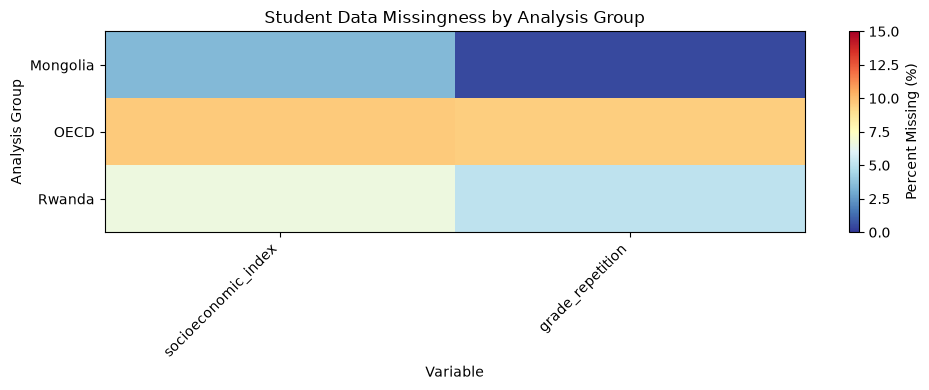

In [13]:
# keeping only missing student variables with some missing data
missing_student_plot = student_missing.loc[
    :, student_missing.max() > 0
]

# creating student missingness plot
plt.figure(figsize=(10, 4))
plt.imshow(missing_student_plot, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=15)
plt.xticks(
    range(len(missing_student_plot.columns)),
    missing_student_plot.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(missing_student_plot.index)),
    missing_student_plot.index
)

# customizing student missingness plot
plt.colorbar(label="Percent Missing (%)")
plt.title("Student Data Missingness by Analysis Group")
plt.xlabel("Variable")
plt.ylabel("Analysis Group")

# displaying student missingness plot
plt.tight_layout()
plt.show()

## 5H. Missingness and Mathematics Performance

In [14]:
# calculating weighted mathematics performance across the 10 plausible values
def weighted_math_mean(data):
    """Calculates weighted mathematics performance across the 10 plausible values."""

    math_columns = [f"math{i}" for i in range(1, 11)]
    weighted_scores = []

    for math_column in math_columns:
        valid_rows = data.dropna(
            subset=[math_column, "student_weight"]
        )

        weighted_score = np.average(
            valid_rows[math_column],
            weights=valid_rows["student_weight"]
        )

        weighted_scores.append(weighted_score)

    return np.mean(weighted_scores)


# comparing students with missing and observed ESCS and grade repetition
missingness_rows = []

for group in ["Mongolia", "Rwanda", "OECD"]:
    group_rows = student_clean[
        student_clean["analysis_group"] == group
    ]

    for variable in ["socioeconomic_index", "grade_repetition"]:

        missing_rows = group_rows[
            group_rows[variable].isna()
        ]

        observed_rows = group_rows[
            group_rows[variable].notna()
        ]

        missing_math = weighted_math_mean(missing_rows)
        observed_math = weighted_math_mean(observed_rows)

        missingness_rows.append({
            "Analysis Group": group,
            "Variable": variable,
            "Missing N": len(missing_rows),
            "Observed N": len(observed_rows),
            "Missing Math": missing_math,
            "Observed Math": observed_math,
            "Difference": missing_math - observed_math
        })


missingness_performance = pd.DataFrame(missingness_rows)

display(
    missingness_performance.round(2)
)

,Analysis Group,Variable,Missing N,Observed N,Missing Math,Observed Math,Difference
0,Mongolia,socioeconomic_index,245,6901,351.16,421.16,-70.01
1,Mongolia,grade_repetition,36,7110,364.84,418.94,-54.09
2,Rwanda,socioeconomic_index,442,6180,267.13,314.94,-47.81
3,Rwanda,grade_repetition,335,6287,273.89,313.70,-39.81
4,OECD,socioeconomic_index,30369,284945,438.02,462.27,-24.25
5,OECD,grade_repetition,30025,285289,475.41,454.04,21.38


### Analysis Note: Data Missingness and Integrity

ESCS missingness is **3.43% in Mongolia, 6.67% in Rwanda, and 9.63% in the pooled OECD comparison group**. Repetition missingness is **0.50%, 5.06%, and 9.52%**, respectively. Weights are complete; achievement and gender are virtually complete, with one OECD student missing all 30 plausible values and 15 missing gender. OECD school-level missingness is roughly **12–14%** for location and shortage measures. School-linked OECD analyses exclude Iceland and Luxembourg because school IDs are unavailable.

Students missing ESCS score about **70 points lower in Mongolia, 48 in Rwanda, and 24 in the pooled OECD comparison group**. Missing repetition also accompanies lower mathematics performance in Mongolia and Rwanda. The pooled OECD repetition pattern reverses the within-country pattern because country availability differs. ESCS and repetition analyses therefore describe selected observed samples. School-condition missingness has heterogeneous achievement associations.

# 6. Overall PISA Performance

For each subject and analysis group, we calculate the student-weighted mean separately for each of PISA's 10 plausible values and then average those 10 estimates.<sup><a href="#endnote-2">2</a></sup> The plausible values are alternative estimates of achievement, not 10 separate tests.

## 6A. Weighted Plausible Value Function

In [15]:
# calculating weighted mean achievement across the 10 plausible values
def weighted_subject_mean(
    data,
    analysis_group,
    subject="math"
):
    """Calculates the weighted mean score across a subject's 10 plausible values."""

    group_rows = data[
        data["analysis_group"] == analysis_group
    ]

    score_columns = [
        f"{subject}{i}" for i in range(1, 11)
    ]

    weighted_scores = []

    # weighted mean for each plausible value
    for score_column in score_columns:
        valid_rows = group_rows.dropna(
            subset=[score_column, "student_weight"]
        )

        weighted_score = np.average(
            valid_rows[score_column],
            weights=valid_rows["student_weight"]
        )

        weighted_scores.append(weighted_score)

    return np.mean(weighted_scores)

## 6B. Overall PISA Performance Summary

In [16]:
# calculating weighted means across subjects and groups
subjects = ["math", "read", "science"]
groups = ["Rwanda", "Mongolia", "OECD"]
performance_results = {}

for group in groups:
    performance_results[group] = {}

    for subject in subjects:
        performance_results[group][subject] = weighted_subject_mean(
            student_clean,
            group,
            subject
        )


# creating weighted performance summary
performance_summary = pd.DataFrame(
    performance_results
).T[
    ["math", "read", "science"]
]

performance_summary.columns = [
    "Mathematics",
    "Reading",
    "Science"
]

print("=== PISA 2025 Weighted Performance Summary ===")
display(performance_summary.round(2))

=== PISA 2025 Weighted Performance Summary ===


,Mathematics,Reading,Science
Rwanda,311.65,300.94,317.29
Mongolia,418.64,374.25,424.03
OECD,458.37,467.21,484.46


**Analysis Note: Overall Performance**

Mongolia outperforms Rwanda across all three domains: the mathematics gap is **106.99 points**, science **106.74**, and reading **73.31**. Both countries remain below the pooled OECD comparison group; Mongolia's mathematics shortfall is **39.73 points**. Its reading and science shortfalls are **92.96 and 60.43 points**, respectively. Rwanda's shortfalls are larger. These results describe substantial performance differences without explaining their sources. The remaining analysis examines associations with student and school characteristics.

# 7. Comparison of Student and School Characteristics

## 7A. Weighted Summary Functions

In [17]:
# calculating weighted population mean
def weighted_population_mean(
    data,
    value_column,
    weight_column="student_weight"
):
    """Calculates a population-weighted mean."""

    valid_rows = data.dropna(
        subset=[value_column, weight_column]
    )
    return np.average(
        valid_rows[value_column],
        weights=valid_rows[weight_column]
    )

# calculating weighted percentage for one category
def weighted_percentage(
    data,
    category_column,
    category_value,
    weight_column="student_weight"
):
    """Calculates the weighted percentage in one category."""

    valid_rows = data.dropna(
        subset=[category_column, weight_column]
    )
    matching_weight = valid_rows[
        valid_rows[category_column] == category_value
    ][weight_column].sum()

    total_weight = valid_rows[weight_column].sum()
    return (matching_weight / total_weight) * 100




## 7B. Student and School Characteristics Summary

In [18]:
# calculating student and school characteristics by group
groups = ["Mongolia", "Rwanda", "OECD"]
summary_rows = []

for group in groups:
    school_rows = school_clean[
        school_clean["analysis_group"] == group
    ]
    student_rows = student_clean[
        student_clean["analysis_group"] == group
    ]
    # attaching school characteristics to students
    student_school_rows = student_rows[
        ["school_id", "student_weight"]
    ].merge(
        school_rows[
            [
                "school_id",
                "school_location",
                "edu_material_shortage",
                "staff_shortage"
            ]
        ],
        on="school_id",
        how="inner",
        validate="many_to_one"
    )

    # storing summary statistics for each group
    summary_rows.append({
        "Analysis Group": group,
        "Male Students (%)": weighted_percentage(
            student_rows,
            "is_male",
            1.0
        ),
        "Grade Repetition Rate (%)": weighted_percentage(
            student_rows,
            "grade_repetition",
            1.0
        ),
        "Mean ESCS (Socioeconomic)": weighted_population_mean(
            student_rows,
            "socioeconomic_index"
        ),
        "Reported Urban School Location (%)": (
    weighted_percentage(
        student_school_rows,
        "school_location",
        4.0
    )
    +
    weighted_percentage(
        student_school_rows,
        "school_location",
        5.0
    )
    +
    weighted_percentage(
        student_school_rows,
        "school_location",
        6.0
    )
),
        "Educational Material Shortage (Mean)": weighted_population_mean(
            student_school_rows,
            "edu_material_shortage"
        ),
        "Staff Shortage Index (Mean)": weighted_population_mean(
            student_school_rows,
            "staff_shortage"
        )
    })


# creating student and school characteristics summary
covariate_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Analysis Group")
)

display(covariate_summary.round(2))

,Male Students (%),Grade Repetition Rate (%),Mean ESCS (Socioeconomic),Reported Urban School Location (%),Educational Material Shortage (Mean),Staff Shortage Index (Mean)
Analysis Group,,,,,,
Mongolia,49.12,5.65,-0.78,47.06,0.04,0.06
Rwanda,43.16,55.70,-2.15,14.41,0.67,0.26
OECD,49.43,11.18,-0.19,48.94,-0.07,0.28


**Location note.** Eleven Rwandan schools, linked to **346 students**, have raw location code 6, labeled communities above 10 million people. Eight schools are in Kigali and one each in South, North, and West; even Kigali is below that threshold.<sup><a href="#endnote-3">3</a></sup> All eleven have urban sampling strata, supporting broad urban grouping rather than literal megacity interpretation. The original cause remains unresolved; these observations are retained and flagged. The public file cannot distinguish unusual responses from a country-specific convention or an earlier coding transformation.

### Analysis Note: Student and School Characteristics

Grade repetition is **55.70% in Rwanda**, compared with **5.65% in Mongolia** and **11.18% in the OECD comparison group**. Mean ESCS is substantially lower in Rwanda (**−2.15**) than Mongolia (**−0.78**) or the OECD comparison group (**−0.19**).

Among students with observed school-location data, **14.41%** of Rwanda's represented students attend schools reported in the broad urban categories, compared with **47.06% in Mongolia** and **48.94% in the pooled OECD comparison group**. Rwanda reports greater educational material shortages (**0.67**) than Mongolia (**0.04**) or the OECD comparison group (**−0.07**). Staff-shortage means are **0.26, 0.06, and 0.28**, respectively.

# 8. Association with Mathematics performance

## 8A. Merge Student and School Data

In [19]:
# merging school characteristics onto student data
student_school_data = student_clean.merge(
    school_clean[
        [
            "school_id",
            "school_location",
            "edu_material_shortage",
            "staff_shortage"
        ]
    ],
    on="school_id",
    how="left",
    validate="many_to_one"
)

# checking that the merge did not create extra student rows
assert len(student_school_data) == len(student_clean)

## 8B. Weighted Mathematics Performance by Category

In [20]:
# calculating weighted math performance by category
def weighted_math_by_category(
    data,
    category_column,
    analysis_group
):
    """Calculates weighted mathematics performance for each category of a variable."""

    group_rows = data[
        data["analysis_group"] == analysis_group
    ]

    math_columns = [
        f"math{i}" for i in range(1, 11)
    ]

    category_scores = {}

    for category, category_rows in group_rows.groupby(
        category_column,
        observed=True
    ):
        weighted_math_scores = []

        for math_column in math_columns:
            valid_rows = category_rows.dropna(
                subset=[math_column, "student_weight"]
            )

            if len(valid_rows) > 0:
                weighted_score = np.average(
                    valid_rows[math_column],
                    weights=valid_rows["student_weight"]
                )

                weighted_math_scores.append(weighted_score)

        if weighted_math_scores:
            category_scores[category] = np.mean(
                weighted_math_scores
            )

    return category_scores

## 8C. Gender and Grade Repetition

In [21]:
# calculating math performance by gender and grade repetition
groups = ["Mongolia", "Rwanda", "OECD"]
subgroup_rows = []

for group in groups:
    gender_scores = weighted_math_by_category(
        student_school_data,
        "is_male",
        group
    )

    repetition_scores = weighted_math_by_category(
        student_school_data,
        "grade_repetition",
        group
    )

    subgroup_rows.append({
        "Analysis Group": group,
        "Female/Other Math": gender_scores.get(0.0, np.nan),
        "Male Math": gender_scores.get(1.0, np.nan),
        "Gender Gap (Male - Female/Other)":
          gender_scores.get(1.0, np.nan)
          - gender_scores.get(0.0, np.nan),
        "No Repetition": repetition_scores.get(0.0, np.nan),
        "Repeated Grade": repetition_scores.get(1.0, np.nan),
        "Repetition Gap (Repeated - No Repetition)":
            repetition_scores.get(1.0, np.nan)
            - repetition_scores.get(0.0, np.nan)
    })

subgroup_math_summary = (
    pd.DataFrame(subgroup_rows)
    .set_index("Analysis Group")
)

print("=== Mathematics Performance by Gender and Grade Repetition ===")
display(subgroup_math_summary.round(2))

=== Mathematics Performance by Gender and Grade Repetition ===


,Female/Other Math,Male Math,Gender Gap (Male - Female/Other),No Repetition,Repeated Grade,Repetition Gap (Repeated - No Repetition)
Analysis Group,,,,,,
Mongolia,422.75,414.38,-8.37,424.08,332.92,-91.17
Rwanda,301.73,324.70,22.97,339.25,293.39,-45.87
OECD,449.13,467.82,18.70,463.56,378.37,-85.19


### Analysis Note: Gender and Grade Repetition

Male students score about **23 points higher** than the female/other group in Rwanda and **19 points higher** in the OECD comparison group, while Mongolia shows an **8-point** difference in the opposite direction. Grade repetition shows much larger differences: repeaters score about **91 points lower in Mongolia, 46 lower in Rwanda, and 85 lower in the OECD comparison group**. These differences are descriptive, not causal.

## 8D. Mathematics Performance Across ESCS Ranges

In [22]:
# creating common ESCS ranges
escs_bins = [
    -np.inf,
    -2.0,
    -1.0,
    0.0,
    1.0,
    np.inf
]

escs_labels = [
    "Below -2.0",
    "-2.0 to -1.0",
    "-1.0 to 0.0",
    "0.0 to 1.0",
    "Above 1.0"
]

student_school_data["escs_range"] = pd.cut(
    student_school_data["socioeconomic_index"],
    bins=escs_bins,
    labels=escs_labels
)


# calculating math performance across common ESCS ranges
math_by_escs = pd.DataFrame({
    group: weighted_math_by_category(
        student_school_data,
        "escs_range",
        group
    )
    for group in groups
})

print("=== Mathematics Performance Across Common ESCS Ranges ===")
display(math_by_escs.round(2))


# counting students in each ESCS range by group
escs_range_counts = (
    student_school_data
    .groupby(
        ["analysis_group", "escs_range"],
        observed=True
    )
    .size()
    .unstack()
    .reindex(groups)
)

print("=== Student Counts Across Common ESCS Ranges ===")
display(escs_range_counts)

=== Mathematics Performance Across Common ESCS Ranges ===


,Mongolia,Rwanda,OECD
Below -2.0,373.89,308.22,381.73
-2.0 to -1.0,400.64,311.44,414.60
-1.0 to 0.0,423.18,328.64,449.65
0.0 to 1.0,461.94,356.10,490.60
Above 1.0,484.69,348.51,516.69


=== Student Counts Across Common ESCS Ranges ===


escs_range,Below -2.0,-2.0 to -1.0,-1.0 to 0.0,0.0 to 1.0,Above 1.0
analysis_group,,,,,
Mongolia,782,2057,2119,1806,137
Rwanda,3536,1361,868,379,36
OECD,9265,37408,79612,109784,48876


### Analysis Note: Socioeconomic Status

Mathematics generally increases with ESCS. Mongolia rises from **373.89** below ESCS −2 to **484.69** above 1, while the OECD comparison group rises from **381.73** to **516.69**. Rwanda rises from **308.22** below −2 to **356.10** between 0 and 1, then falls slightly to **348.51** above 1; only **36 Rwandan students** are in that highest category. Mongolia remains above Rwanda within every common ESCS range.

## 8E. Educational Material Shortages

In [23]:
# creating common educational material shortage categories
material_shortage_bins = [
    -np.inf,
    -0.5,
    0.5,
    np.inf
]

material_shortage_labels = [
    "Low",
    "Moderate",
    "High"
]

student_school_data["material_shortage_category"] = pd.cut(
    student_school_data["edu_material_shortage"],
    bins=material_shortage_bins,
    labels=material_shortage_labels
)

# calculating math performance by educational material shortage
math_by_material_shortage = pd.DataFrame({
    group: weighted_math_by_category(
        student_school_data,
        "material_shortage_category",
        group
    )
    for group in groups
})

print("=== Mathematics Performance by Educational Material Shortage ===")
display(math_by_material_shortage.round(2))

=== Mathematics Performance by Educational Material Shortage ===


,Mongolia,Rwanda,OECD
Low,429.19,334.59,467.50
Moderate,418.56,312.45,458.08
High,406.53,304.38,444.31


### Analysis Note: Educational Material Shortages

Mathematics performance falls as reported educational material shortages increase in all three groups. Students in the high-shortage category score about **23 points lower** than those in the low-shortage category in Mongolia, **30 points lower in Rwanda**, and **23 points lower in the OECD comparison group**.

## 8F. Mathematics Performance by School Location

In [24]:
# grouping reported school locations into broader categories
school_location_group_map = {
    1.0: "Rural (<3,000)",
    2.0: "Town (3,000-100,000)",
    3.0: "Town (3,000-100,000)",
    4.0: "Urban (>100,000)",
    5.0: "Urban (>100,000)",
    6.0: "Urban (>100,000)"
}

student_school_data["school_location_group"] = (
    student_school_data["school_location"]
    .map(school_location_group_map)
)

school_location_order = [
    "Rural (<3,000)",
    "Town (3,000-100,000)",
    "Urban (>100,000)"
]


# calculating mathematics performance by broader school location
math_by_school_location = pd.DataFrame({
    group: weighted_math_by_category(
        student_school_data,
        "school_location_group",
        group
    )
    for group in groups
}).reindex(school_location_order)

print("=== Mathematics Performance by Reported School Location ===")
display(math_by_school_location.round(2))

=== Mathematics Performance by Reported School Location ===


,Mongolia,Rwanda,OECD
"Rural (<3,000)",376.00,304.00,410.15
"Town (3,000-100,000)",401.98,315.96,458.78
"Urban (>100,000)",438.09,344.77,464.70


In [25]:
# checking whether Rwanda's category-6 responses drive the urban result
rwanda_location_rows = student_school_data[
    (student_school_data["analysis_group"] == "Rwanda")
    & (student_school_data["school_location"].notna())
].copy()

# creating a simple urban versus rural/town comparison
rwanda_location_rows["urban_status"] = np.where(
    rwanda_location_rows["school_location"].isin([4.0, 5.0, 6.0]),
    "Urban (>100,000)",
    "Rural/Town (<100,000)"
)

location_sensitivity_rows = []

for scenario, scenario_rows in [
    ("All Reported Locations", rwanda_location_rows),
    (
        "Excluding Category 6",
        rwanda_location_rows[
            rwanda_location_rows["school_location"] != 6.0
        ]
    )
]:

    location_scores = weighted_math_by_category(
        scenario_rows,
        "urban_status",
        "Rwanda"
    )

    urban_percentage = weighted_percentage(
        scenario_rows,
        "urban_status",
        "Urban (>100,000)"
    )

    urban_math = location_scores.get(
        "Urban (>100,000)",
        np.nan
    )

    rural_town_math = location_scores.get(
        "Rural/Town (<100,000)",
        np.nan
    )

    location_sensitivity_rows.append({
        "Scenario": scenario,
        "Urban Students (%)": urban_percentage,
        "Urban Math": urban_math,
        "Rural/Town Math": rural_town_math,
        "Urban - Rural/Town Gap":
            urban_math - rural_town_math
    })


rwanda_location_sensitivity = (
    pd.DataFrame(location_sensitivity_rows)
    .set_index("Scenario")
)

print("=== Rwanda School Location Sensitivity Check ===")
display(rwanda_location_sensitivity.round(2))

=== Rwanda School Location Sensitivity Check ===


,Urban Students (%),Urban Math,Rural/Town Math,Urban - Rural/Town Gap
Scenario,,,,
All Reported Locations,14.41,344.77,306.43,38.34
Excluding Category 6,9.86,342.38,306.43,35.95


### Analysis Note: School Location

Rwandan students in reported urban schools score higher than those in rural or town schools. Excluding the 11 schools with anomalous location responses changes the urban–rural/town gap from about **38 to 36 points**, preserving its descriptive direction. This sensitivity check does not validate detailed population categories, which remain uncertain.

## 8G. Weighted Correlation Analysis

In [26]:
# calculating weighted Pearson correlation
def weighted_correlation(x, y, weights):
    """Calculates a weighted Pearson correlation."""

    x_mean = np.average(x, weights=weights)
    y_mean = np.average(y, weights=weights)

    weighted_covariance = np.average(
        (x - x_mean) * (y - y_mean),
        weights=weights
    )

    x_variance = np.average(
        (x - x_mean) ** 2,
        weights=weights
    )

    y_variance = np.average(
        (y - y_mean) ** 2,
        weights=weights
    )

    return weighted_covariance / np.sqrt(
        x_variance * y_variance
    )


# calculating weighted math correlation across the 10 plausible values
def weighted_math_correlation(
    data,
    analysis_group,
    variable_column
):
    """Calculates the average weighted correlation across the 10 math plausible values."""

    group_rows = data[
        data["analysis_group"] == analysis_group
    ]

    math_columns = [
        f"math{i}" for i in range(1, 11)
    ]

    correlations = []

    for math_column in math_columns:
        valid_rows = group_rows.dropna(
            subset=[
                math_column,
                variable_column,
                "student_weight"
            ]
        )

        correlation = weighted_correlation(
            valid_rows[math_column],
            valid_rows[variable_column],
            valid_rows["student_weight"]
        )

        correlations.append(correlation)

    return np.mean(correlations)


# calculating math correlations with student and school characteristics
correlation_rows = []

for group in groups:
    correlation_rows.append({
        "Analysis Group": group,

        "ESCS": weighted_math_correlation(
            student_school_data,
            group,
            "socioeconomic_index"
        ),

        "Material Shortage": weighted_math_correlation(
            student_school_data,
            group,
            "edu_material_shortage"
        ),

        "Staff Shortage": weighted_math_correlation(
            student_school_data,
            group,
            "staff_shortage"
        )
    })


# creating correlation summary
correlation_summary = (
    pd.DataFrame(correlation_rows)
    .set_index("Analysis Group")
)

print("=== Weighted Correlations with Mathematics Performance ===")
display(correlation_summary.round(3))



=== Weighted Correlations with Mathematics Performance ===


,ESCS,Material Shortage,Staff Shortage
Analysis Group,,,
Mongolia,0.376,-0.124,-0.017
Rwanda,0.143,-0.161,-0.098
OECD,0.395,-0.103,-0.049


### Analysis Note: Correlations with Mathematics

ESCS has the clearest positive correlation with mathematics in Mongolia (**0.376**) and the OECD comparison group (**0.395**), while the relationship is weaker in Rwanda (**0.143**). Material shortages are negatively correlated with mathematics in all three groups, with the largest absolute correlation in Rwanda (**−0.161**). Staff-shortage correlations are weaker. These simple correlations do not account for other differences between students or schools.

# 9. Key Visualizations

## 9A. Overall PISA Performance

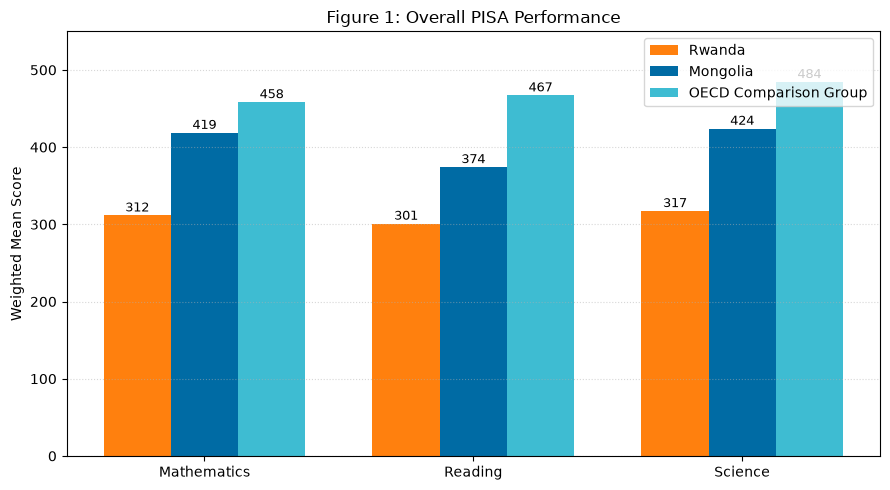

In [27]:
# plotting overall weighted achievement across PISA domains
subjects = ["Mathematics", "Reading", "Science"]
x = np.arange(len(subjects))
width = 0.25

group_colors = {
    "Rwanda": "#FF800E",
    "Mongolia": "#006BA4",
    "OECD": "#3EBCD2"
}


# Figure 1: bar chart with zero baseline
plt.figure(figsize=(9, 5))

bars_rwanda = plt.bar(
    x - width,
    performance_summary.loc["Rwanda", subjects],
    width,
    label="Rwanda",
    color=group_colors["Rwanda"]
)

bars_mongolia = plt.bar(
    x,
    performance_summary.loc["Mongolia", subjects],
    width,
    label="Mongolia",
    color=group_colors["Mongolia"]
)

bars_oecd = plt.bar(
    x + width,
    performance_summary.loc["OECD", subjects],
    width,
    label="OECD Comparison Group",
    color=group_colors["OECD"]
)

# adding value labels above bars
for bars in [bars_rwanda, bars_mongolia, bars_oecd]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 5,
            f"{height:.0f}",
            ha="center",
            fontsize=9
        )

plt.ylabel("Weighted Mean Score")
plt.title("Figure 1: Overall PISA Performance")
plt.xticks(x, subjects)
plt.ylim(0, 550)
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()




## 9B. Student Population Characteristics

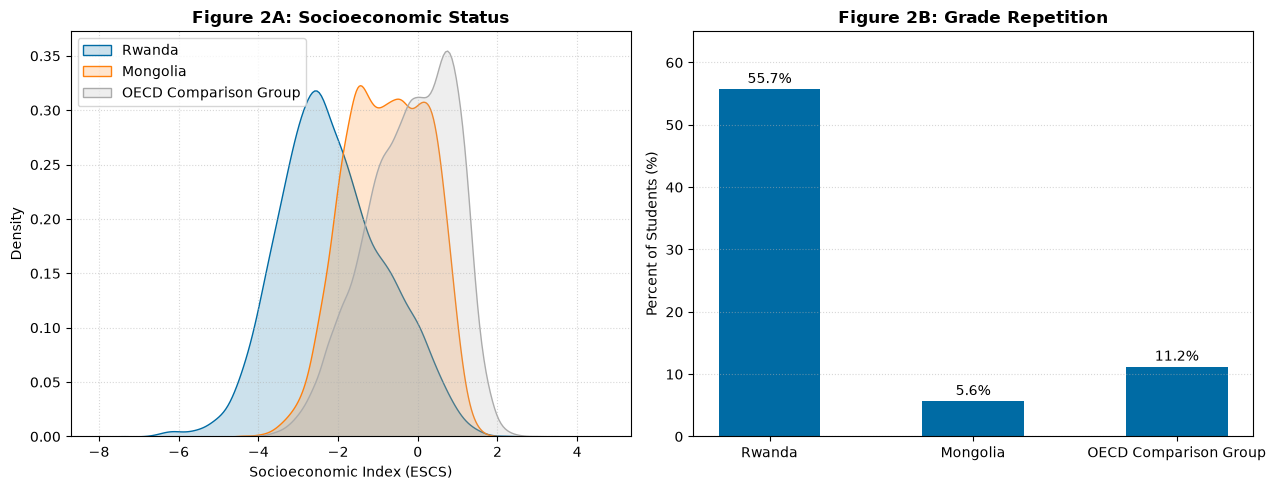

In [28]:
# Figure 2A and 2B: student population characteristics
plt.style.use("tableau-colorblind10")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# Figure 2A: weighted ESCS distributions
for group in ["Rwanda", "Mongolia", "OECD"]:
    group_rows = student_clean[
        student_clean["analysis_group"] == group
    ]

    display_label = (
        "OECD Comparison Group"
        if group == "OECD"
        else group
    )

    sns.kdeplot(
        data=group_rows,
        x="socioeconomic_index",
        weights="student_weight",
        ax=axes[0],
        label=display_label,
        fill=True,
        alpha=0.20
    )

axes[0].set_title(
    "Figure 2A: Socioeconomic Status",
    fontweight="bold"
)
axes[0].set_xlabel("Socioeconomic Index (ESCS)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(linestyle=":", alpha=0.5)


# Figure 2B: grade repetition rates
repetition_rates = [
    covariate_summary.loc[
        "Rwanda",
        "Grade Repetition Rate (%)"
    ],
    covariate_summary.loc[
        "Mongolia",
        "Grade Repetition Rate (%)"
    ],
    covariate_summary.loc[
        "OECD",
        "Grade Repetition Rate (%)"
    ]
]

group_labels = [
    "Rwanda",
    "Mongolia",
    "OECD Comparison Group"
]

bars = axes[1].bar(
    group_labels,
    repetition_rates,
    width=0.5
)

axes[1].set_title(
    "Figure 2B: Grade Repetition",
    fontweight="bold"
)
axes[1].set_ylabel("Percent of Students (%)")
axes[1].set_ylim(0, 65)
axes[1].grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

# adding percentage labels
for bar, rate in zip(bars, repetition_rates):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        rate + 1,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 9C. Mathematics Across ESCS Ranges

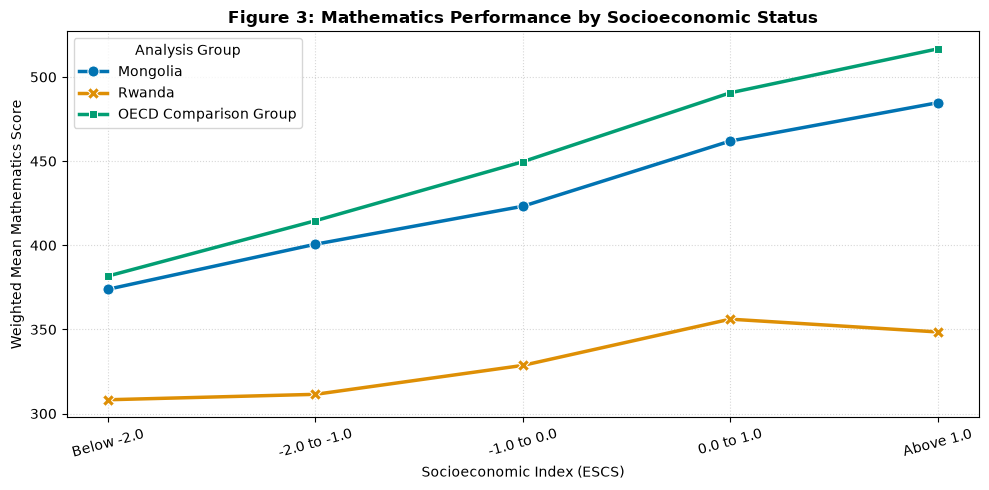

In [29]:
# reshaping ESCS results for visualization
plot_escs = (
    math_by_escs
    .rename(columns={"OECD": "OECD Comparison Group"})
    .rename_axis("ESCS Range")
    .reset_index()
    .melt(
        id_vars="ESCS Range",
        var_name="Analysis Group",
        value_name="Math Score"
    )
)

# keeping ESCS ranges in their correct order
plot_escs["ESCS Range"] = pd.Categorical(
    plot_escs["ESCS Range"],
    categories=escs_labels,
    ordered=True
)


# plotting mathematics performance across ESCS ranges
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=plot_escs,
    x="ESCS Range",
    y="Math Score",
    hue="Analysis Group",
    style="Analysis Group",
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2.5,
    palette="colorblind"
)

plt.title(
    "Figure 3: Mathematics Performance by Socioeconomic Status",
    fontweight="bold"
)

plt.xlabel("Socioeconomic Index (ESCS)")
plt.ylabel("Weighted Mean Mathematics Score")
plt.xticks(rotation=15)
plt.grid(linestyle=":", alpha=0.5)
plt.legend(title="Analysis Group")

plt.tight_layout()
plt.show()

## 9D. Grade Repetition and Material Shortage Comparisons

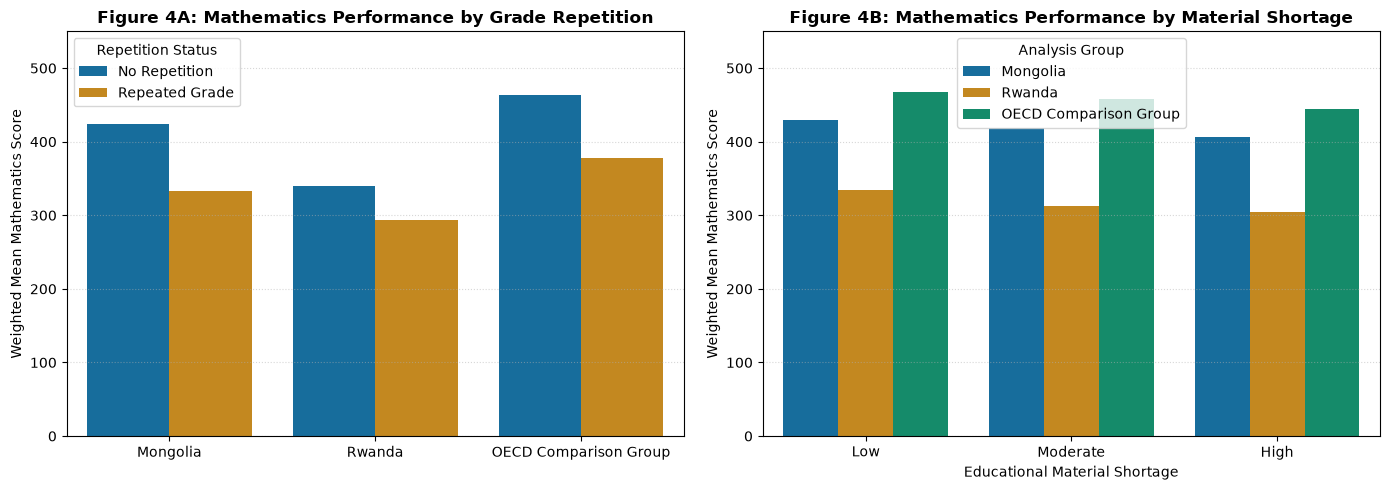

In [30]:
# preparing grade repetition results for visualization
repetition_plot_data = (
    subgroup_math_summary[
        ["No Repetition", "Repeated Grade"]
    ]
    .rename(index={"OECD": "OECD Comparison Group"})
    .reset_index()
    .melt(
        id_vars="Analysis Group",
        var_name="Repetition Status",
        value_name="Math Score"
    )
)


# preparing material shortage results for visualization
material_shortage_plot_data = (
    math_by_material_shortage
    .rename(columns={"OECD": "OECD Comparison Group"})
    .rename_axis("Shortage Level")
    .reset_index()
    .melt(
        id_vars="Shortage Level",
        var_name="Analysis Group",
        value_name="Math Score"
    )
)

material_shortage_plot_data["Shortage Level"] = pd.Categorical(
    material_shortage_plot_data["Shortage Level"],
    categories=["Low", "Moderate", "High"],
    ordered=True
)


# plotting grade repetition and educational material shortage results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Figure 4A: mathematics performance by grade repetition
sns.barplot(
    data=repetition_plot_data,
    x="Analysis Group",
    y="Math Score",
    hue="Repetition Status",
    ax=axes[0],
    palette="colorblind"
)

axes[0].set_title(
    "Figure 4A: Mathematics Performance by Grade Repetition",
    fontweight="bold"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Weighted Mean Mathematics Score")
axes[0].set_ylim(0, 550)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)


# Figure 4B: mathematics performance by material shortage
sns.barplot(
    data=material_shortage_plot_data,
    x="Shortage Level",
    y="Math Score",
    hue="Analysis Group",
    ax=axes[1],
    palette="colorblind"
)

axes[1].set_title(
    "Figure 4B: Mathematics Performance by Material Shortage",
    fontweight="bold"
)
axes[1].set_xlabel("Educational Material Shortage")
axes[1].set_ylabel("Weighted Mean Mathematics Score")
axes[1].set_ylim(0, 550)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# 10. Conclusion and Recommendations

Mongolia substantially outperforms Rwanda in PISA 2025, and the within-country results highlight socioeconomic status, grade repetition, and material shortages as important areas for further study. The analysis also shows that data quality affects interpretation: missing ESCS and repetition information is associated with student performance, and Rwanda's detailed school-location responses contain an implausible category. Future data collection could flag implausible responses during collection, monitor missing responses before fieldwork ends, and cross-check school information against administrative or sampling records. These findings should guide further policy evaluation rather than be treated as evidence that changing any single factor would cause higher mathematics achievement.

# Endnotes

1. <a id="endnote-1"></a>OECD, *PISA 2025 Database*, https://www.oecd.org/en/data/datasets/pisa-2025-database.html
2. <a id="endnote-2"></a>OECD, *PISA Research Documentation: How to Prepare and Analyse the PISA Database*, https://www.oecd.org/en/about/programmes/pisa/how-to-prepare-and-analyse-the-pisa-database.html
3. <a id="endnote-3"></a>National Institute of Statistics of Rwanda, *Fifth Rwanda Population and Housing Census 2022: Main Indicators Report*, https://alpha.statistics.gov.rw/sites/default/files/documents/2025-02/RPHC5_MainIndicatorsReport_Final.pdf


# Generative AI Acknowledgment

ChatGPT and OpenAI Codex were used for Python debugging, code review, data-quality auditing, reproducibility checks, and editorial feedback. The authors reviewed the code, verified the calculations against the underlying PISA data, and are responsible for the final analysis and interpretation.
